# Explore the behavior of Grover's search algorithm on two Subset-Sum instances.

## Find the optimal number of iterations for two puzzles

Your goal is to calculate the optimal number of iterations for two small subset-sum puzzles based on the size of the search space ($N = 2^n$) and the known number of problem solutions ($M$). Write the answer and your calculations below.

### Puzzle 1
**Weights:** `[2, 3, 5]`
**Target Sum:** `5`

**Calculations:**
* **Search Space ($N$):** 3 items means $N = 2^3 = 8$.
* **Solutions ($M$):** There are 2 valid subsets: `[0, 0, 1]` (just 5) and `[1, 1, 0]` (2 + 3). So, $M = 2$.
* **Optimal Iterations:** $\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \rfloor = \lfloor \frac{\pi}{4} \sqrt{\frac{8}{2}} \rfloor = \lfloor \frac{\pi}{4} (2) \rfloor = \lfloor 1.57 \rfloor = 1$ iteration.

---

### Puzzle 2
**Weights:** `[1, 2, 4, 8, 16]`
**Target Sum:** `10`

**Calculations:**
* **Search Space ($N$):** 5 items means $N = 2^5 = 32$.
* **Solutions ($M$):** There is exactly 1 valid subset: `[0, 1, 0, 1, 0]` (2 + 8). So, $M = 1$.
* **Optimal Iterations:** $\lfloor \frac{\pi}{4} \sqrt{\frac{32}{1}} \rfloor = \lfloor \frac{\pi}{4} (5.65) \rfloor = \lfloor 4.44 \rfloor = 4$ iterations.

In [1]:
from psiqworkbench import QPU, Qubits

def run_subset_sum_grover(weights: list[int], target: int, marking_oracle: callable, diffusion: callable, n_iter: int) -> str:
    n_items = len(weights)
    
    # Dynamically allocate qubit count
    max_val = max(sum(weights), target)
    sum_bits = max(1, max_val.bit_length())
    total_qubits = n_items + sum_bits + 1
    
    # Initialize QPU
    qpu = QPU(num_qubits=total_qubits)
    
    # Pre-allocate BOTH registers once
    search_reg = Qubits(n_items, "search", qpu)
    sum_reg = Qubits(sum_bits, "sum", qpu) 
    
    # Equal Superposition
    for i in range(n_items):
        search_reg[i].had()
        
    # Grover Iterations
    for _ in range(n_iter):
        # Apply Phase Oracle (Pass the pre-allocated sum_reg in!)
        marking_oracle(search_reg=search_reg, weights=weights, target=target, cond=None, sum_reg=sum_reg)
        
        # Apply Reflection about the mean
        diffusion(search_reg=search_reg, cond=None)
        
    # Measure and format as binary string
    meas_val = search_reg.read()
    return (f"{{:0>{n_items}b}}").format(meas_val)[::-1]

In [2]:
import matplotlib.pyplot as plt
from collections import Counter
from functools import partial
from src.oracle import subset_sum_oracle
from src.diffusion import diffusion_operator

def get_results(weights, target, iterations):
    shots = 100
    results = []
    
    # Calculate qubits used
    n_items = len(weights)
    max_val = max(sum(weights), target)
    sum_bits = max(1, max_val.bit_length())
    total_qubits = n_items + sum_bits + 1
    
    print(f" Total Qubits: {total_qubits}")
    print(f" Search Register Qubit Count: {n_items}")
    print(f" Sum Register Qubuit Count: {sum_bits}")
    print(f" QPU Buffer: 1 qubit\n") # allocate for buffer
    
    for _ in range(shots):
        res_str = run_subset_sum_grover(
            weights=weights, 
            target=target, 
            marking_oracle=subset_sum_oracle, 
            diffusion=diffusion_operator, 
            n_iter=iterations
        )
        results.append(res_str)
    return results

def plot_results(results, title="Histogram of Subset-Sum Solutions"):
    string_counts = Counter(results)
    labels, values = zip(*sorted(string_counts.items()))
    
    plt.bar(labels, values)
    plt.xlabel('Subset Selection (Binary)')
    plt.xticks(rotation=90)
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

Edit the puzzle parameters and the number of iterations in the code cell below and run it to solve puzzle 1 and plot the results. **Which of the results are correct puzzle solutions?**

 Total Qubits: 8
 Search Register Qubit Count: 3
 Sum Register Qubuit Count: 4
 QPU Buffer: 1 qubit



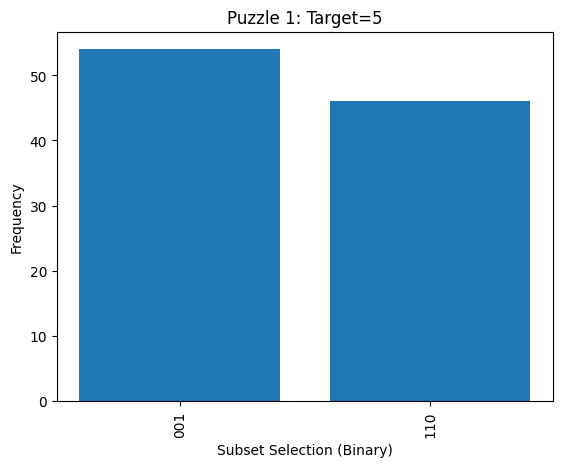

In [3]:
weights_1 = [2, 3, 5]
target_1 = 5
iterations_1 = 1

results_1 = get_results(weights_1, target_1, iterations_1)
plot_results(results_1, title="Puzzle 1: Target=5")

Edit the puzzle parameters and the number of iterations in the code cell below and run it to solve puzzle 2 and plot the results. **Which of the results are correct puzzle solutions?**

 Total Qubits: 11
 Search Register Qubit Count: 5
 Sum Register Qubuit Count: 5
 QPU Buffer: 1 qubit



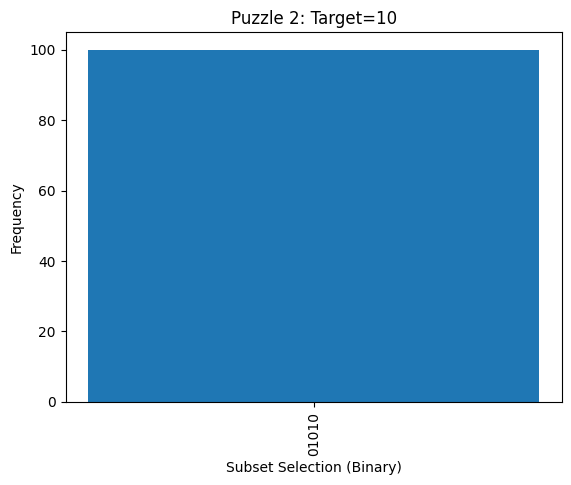

In [4]:
weights_2 = [1, 2, 4, 8, 16]
target_2 = 10
iterations_2 = 4

results_2 = get_results(weights_2, target_2, iterations_2)
plot_results(results_2, title="Puzzle 2: Target=10")